In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, TwoSlopeNorm
from matplotlib import cm
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import seaborn as sns

import os
import sys
parent_dir = Path.cwd().parent
sys.path.append(str(parent_dir))
from plot_phases import plot_cont_phase_diagram, plot_discrete_phase_diagram, plot_differences

<Figure size 1400x1000 with 0 Axes>

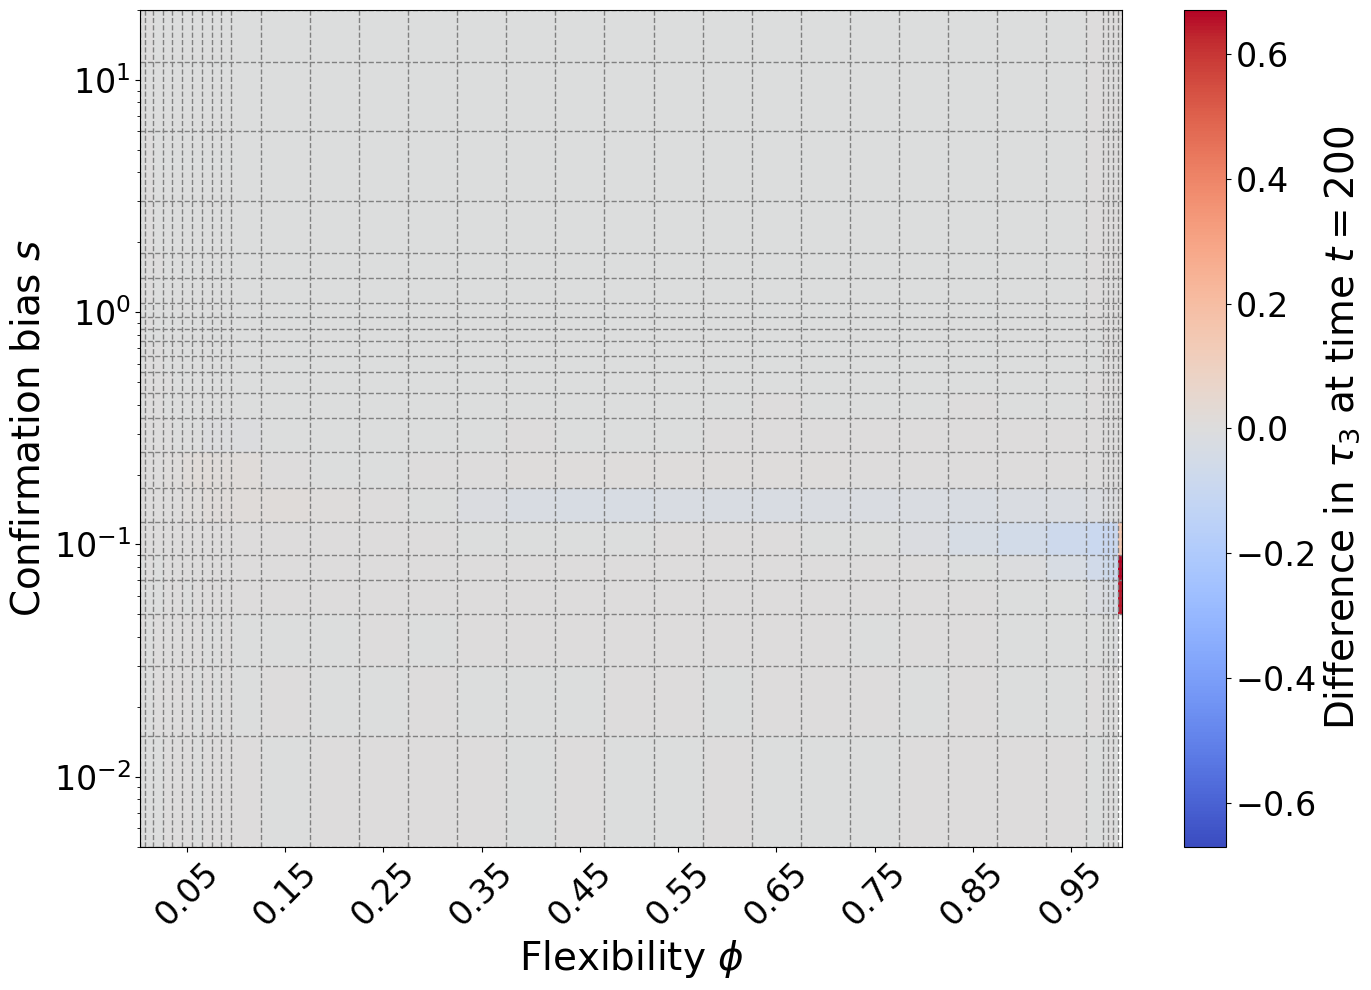

<Figure size 1400x1000 with 0 Axes>

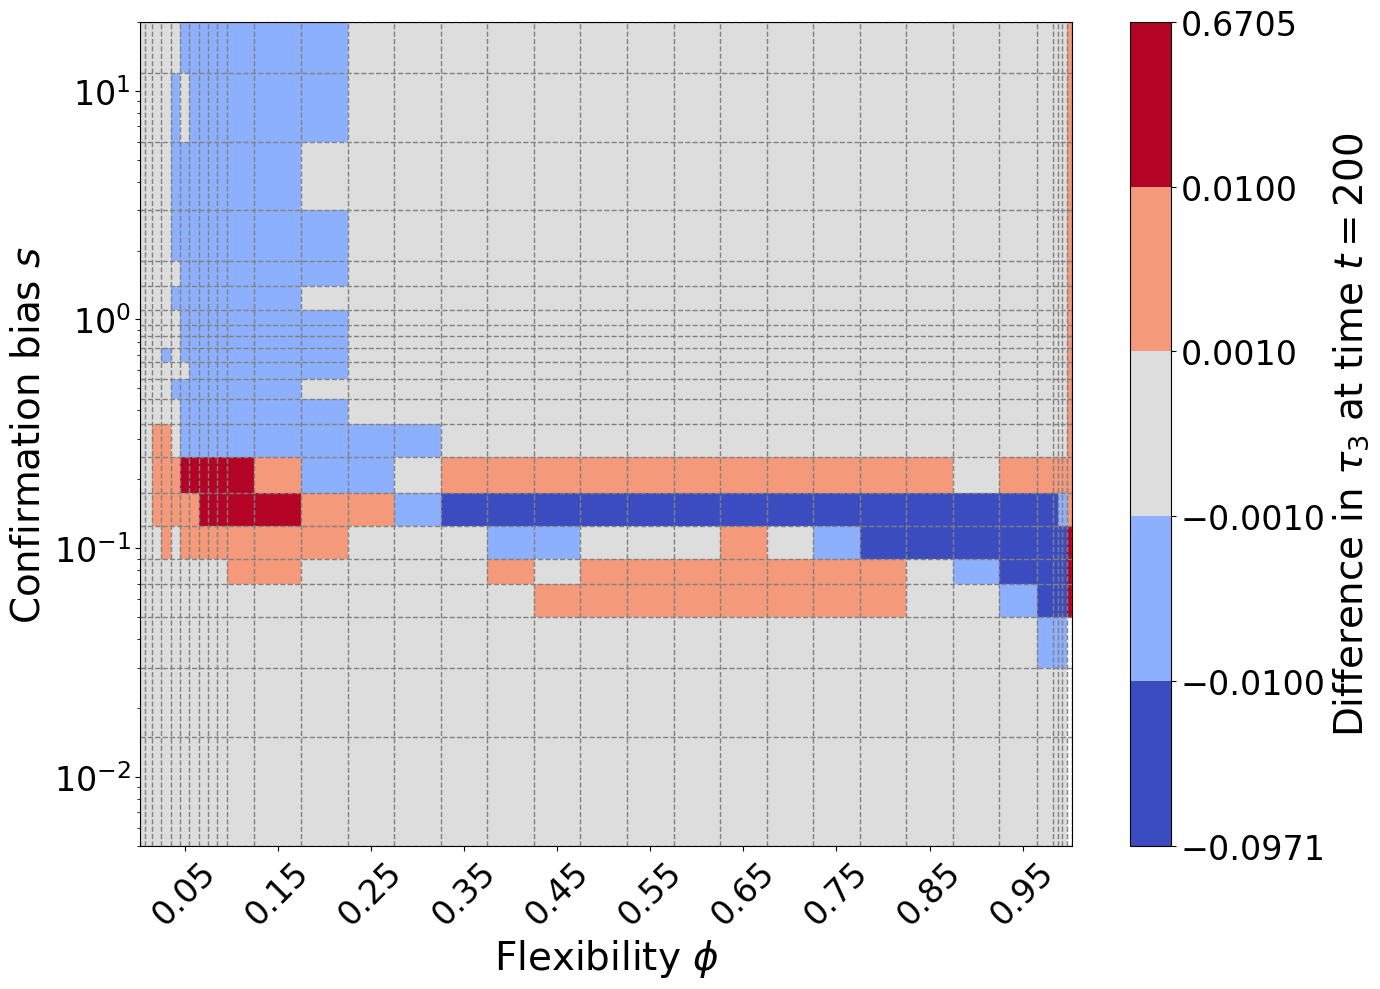

<Figure size 1400x1000 with 0 Axes>

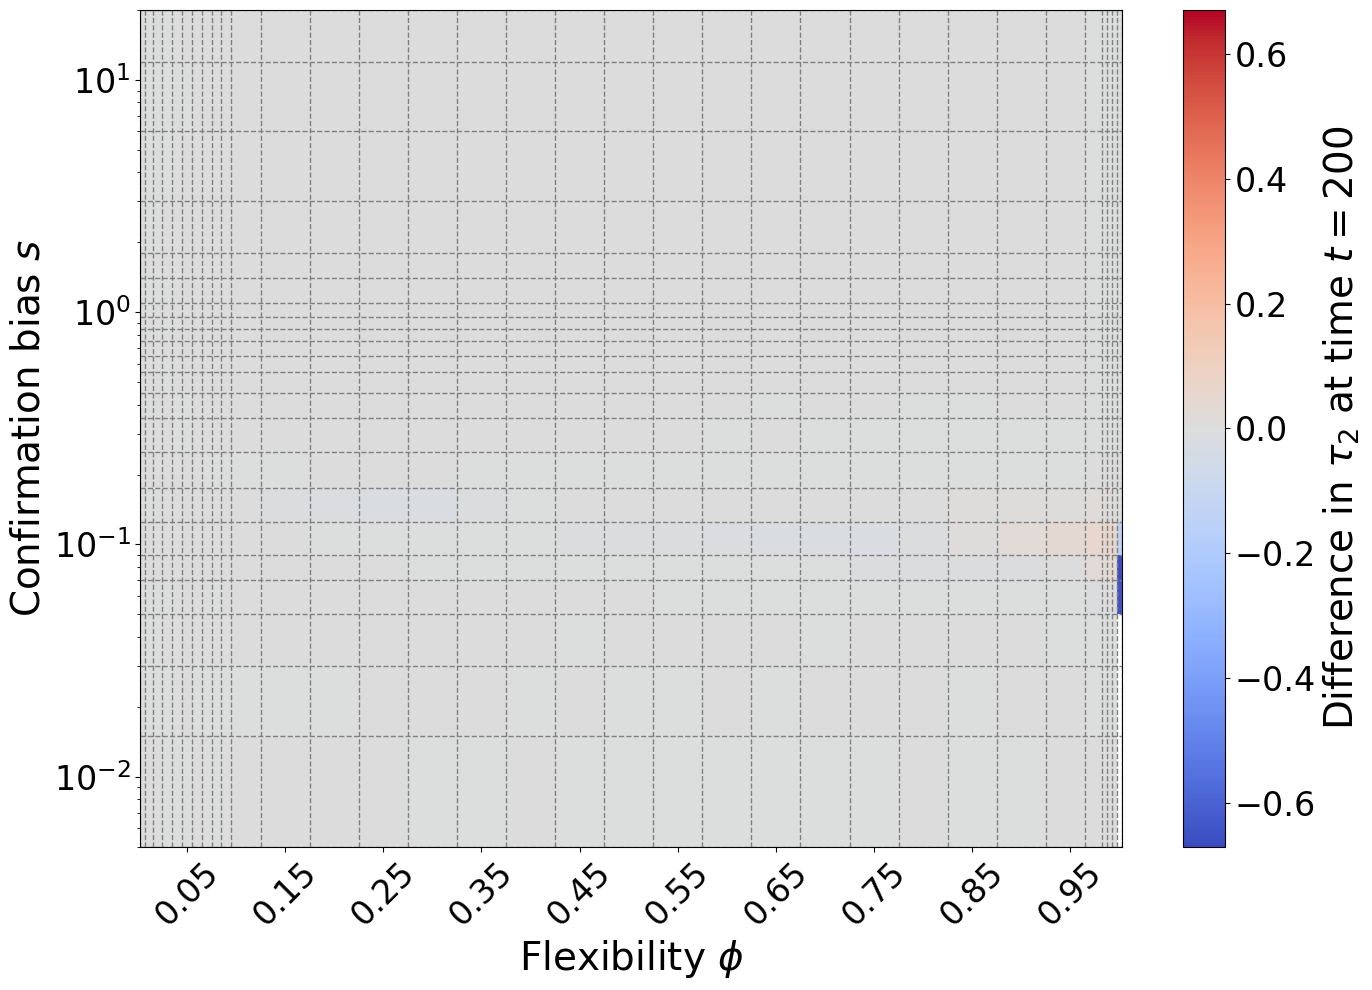

<Figure size 1400x1000 with 0 Axes>

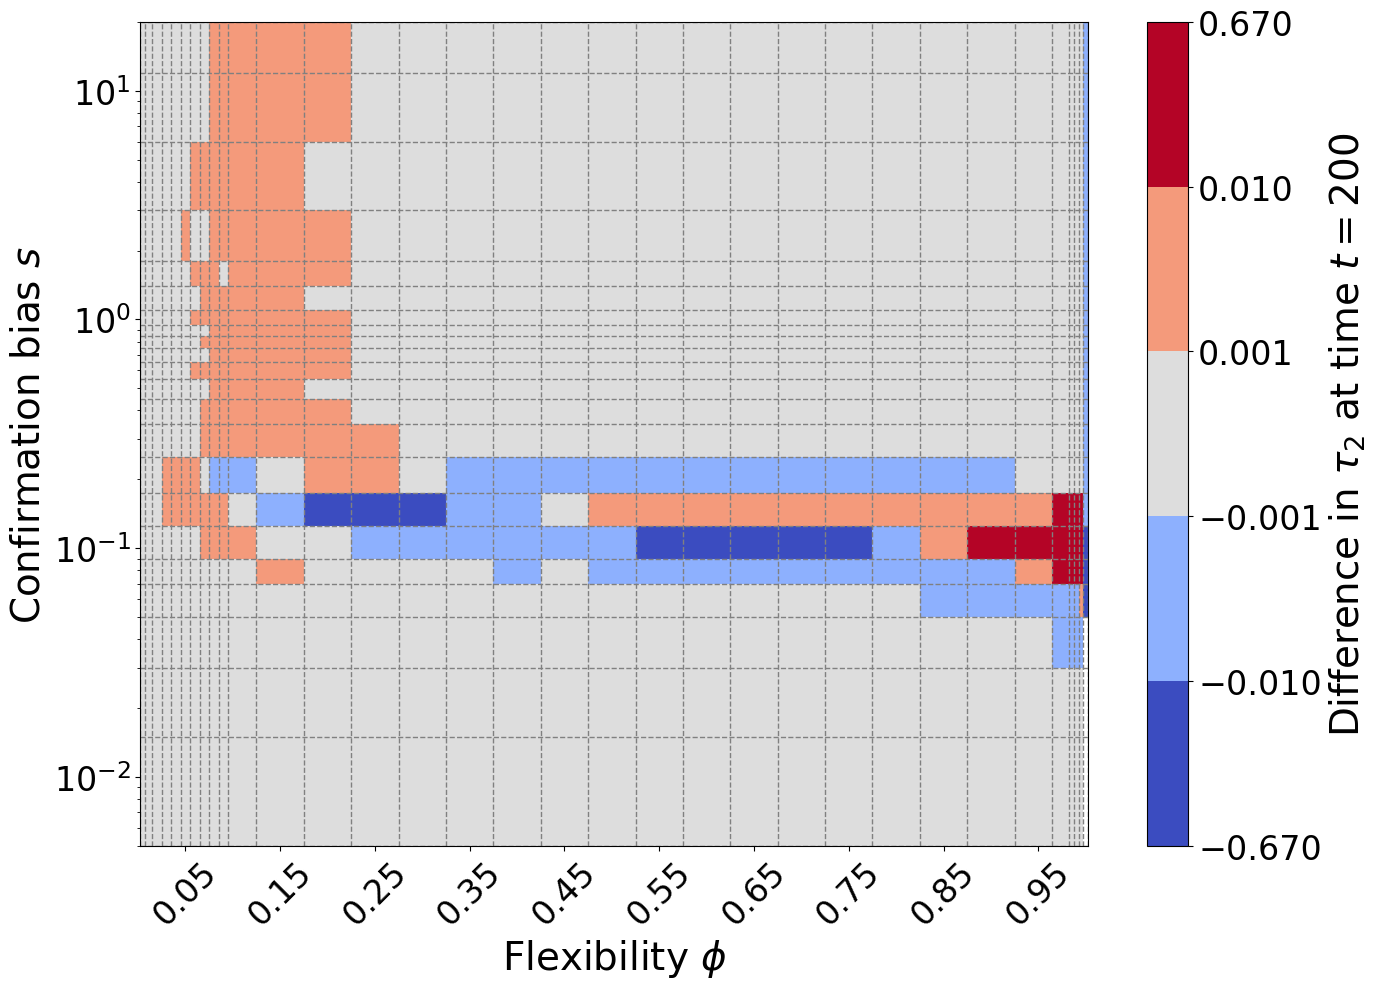

<Figure size 1400x1000 with 0 Axes>

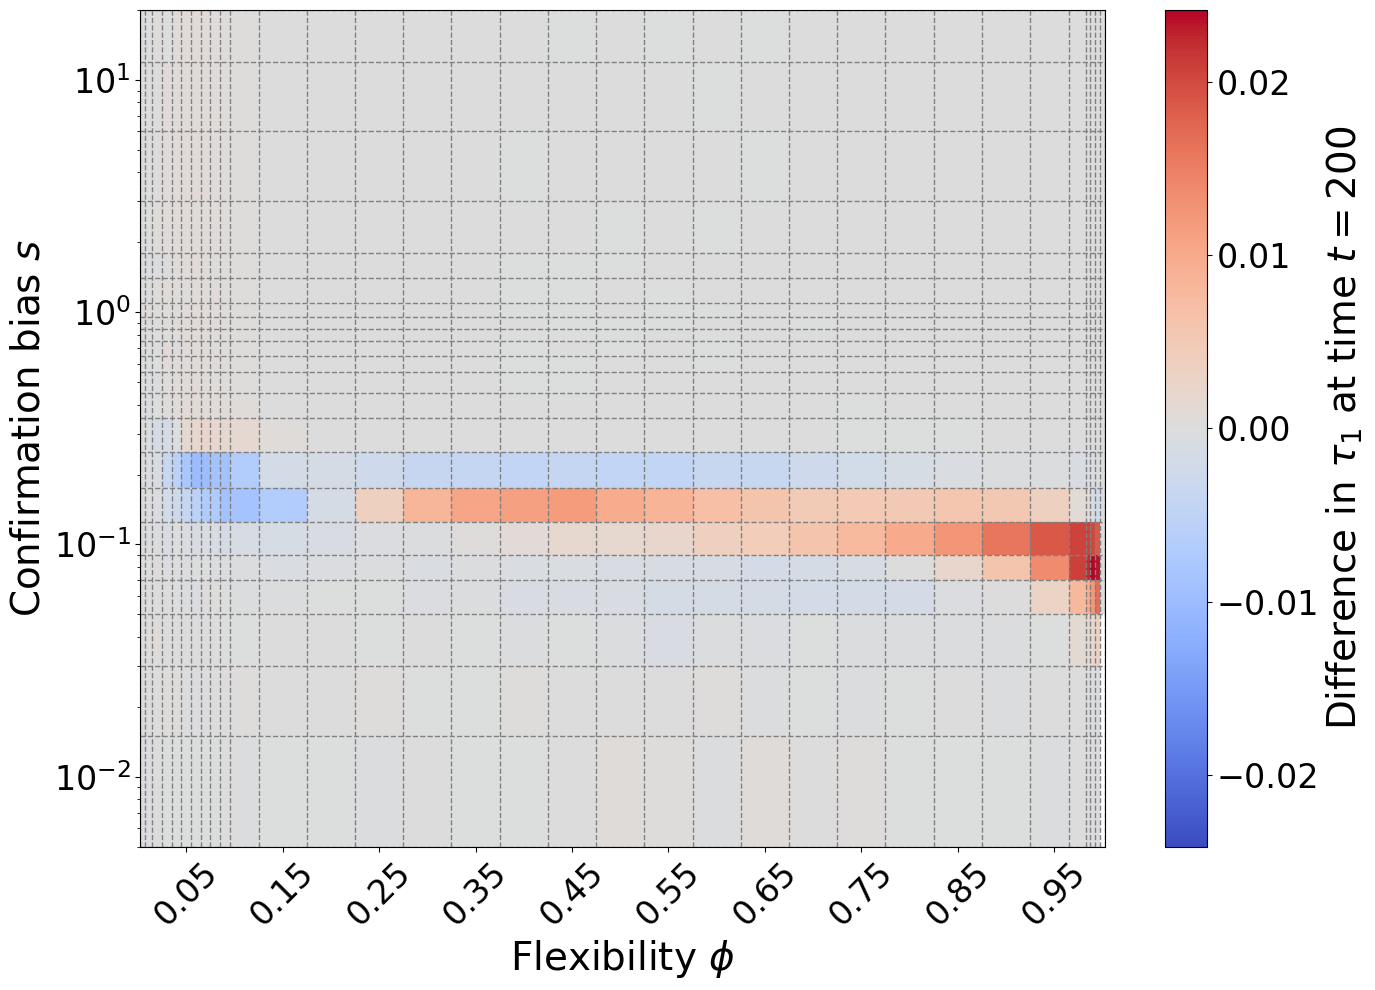

<Figure size 1400x1000 with 0 Axes>

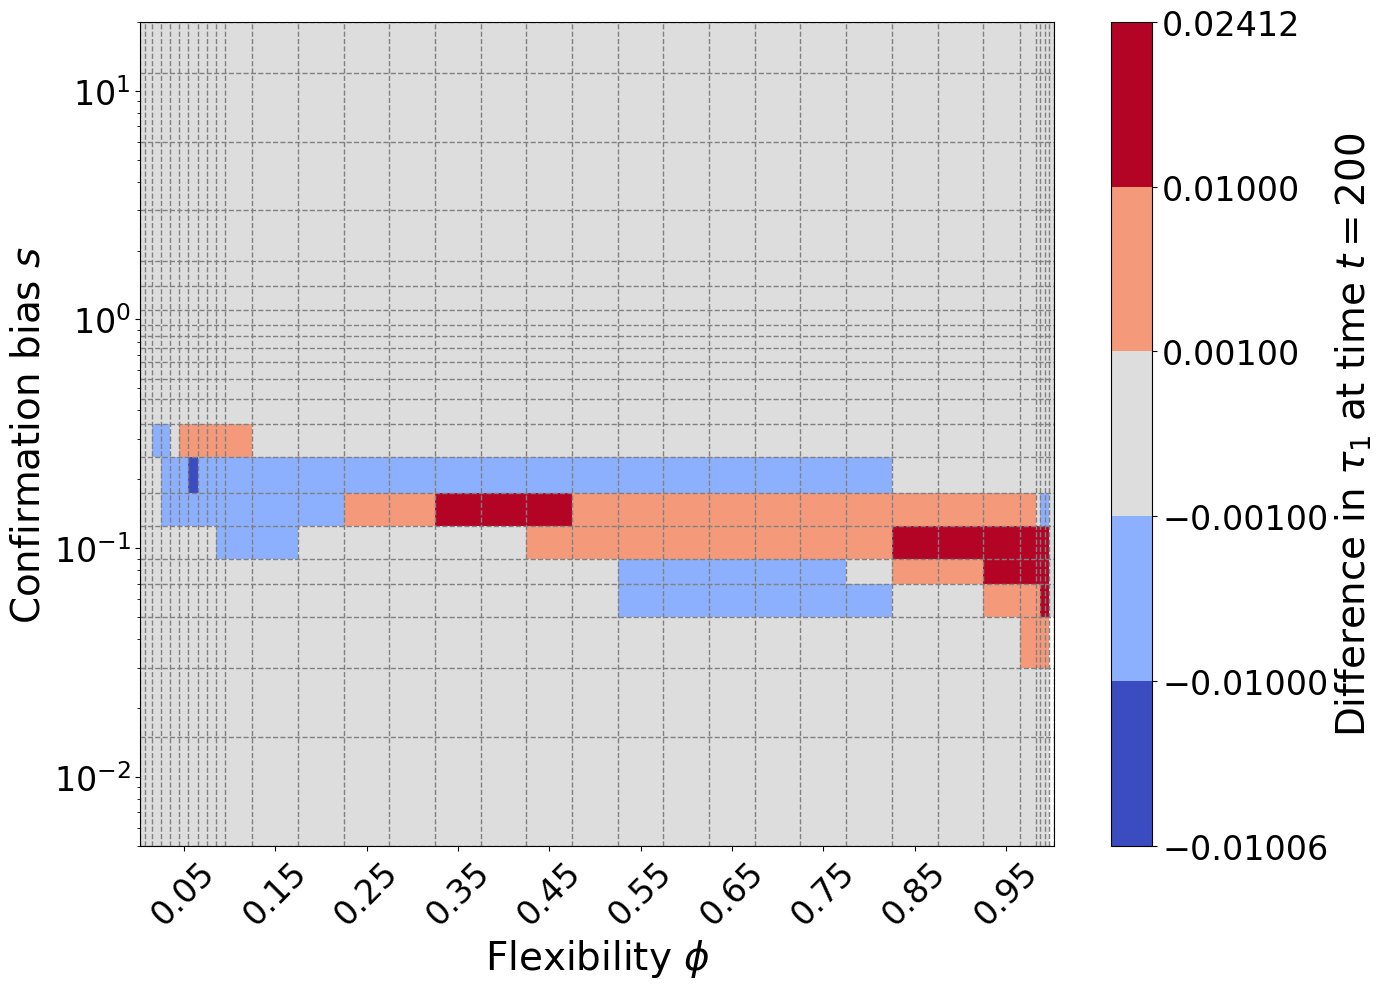

<Figure size 1400x1000 with 0 Axes>

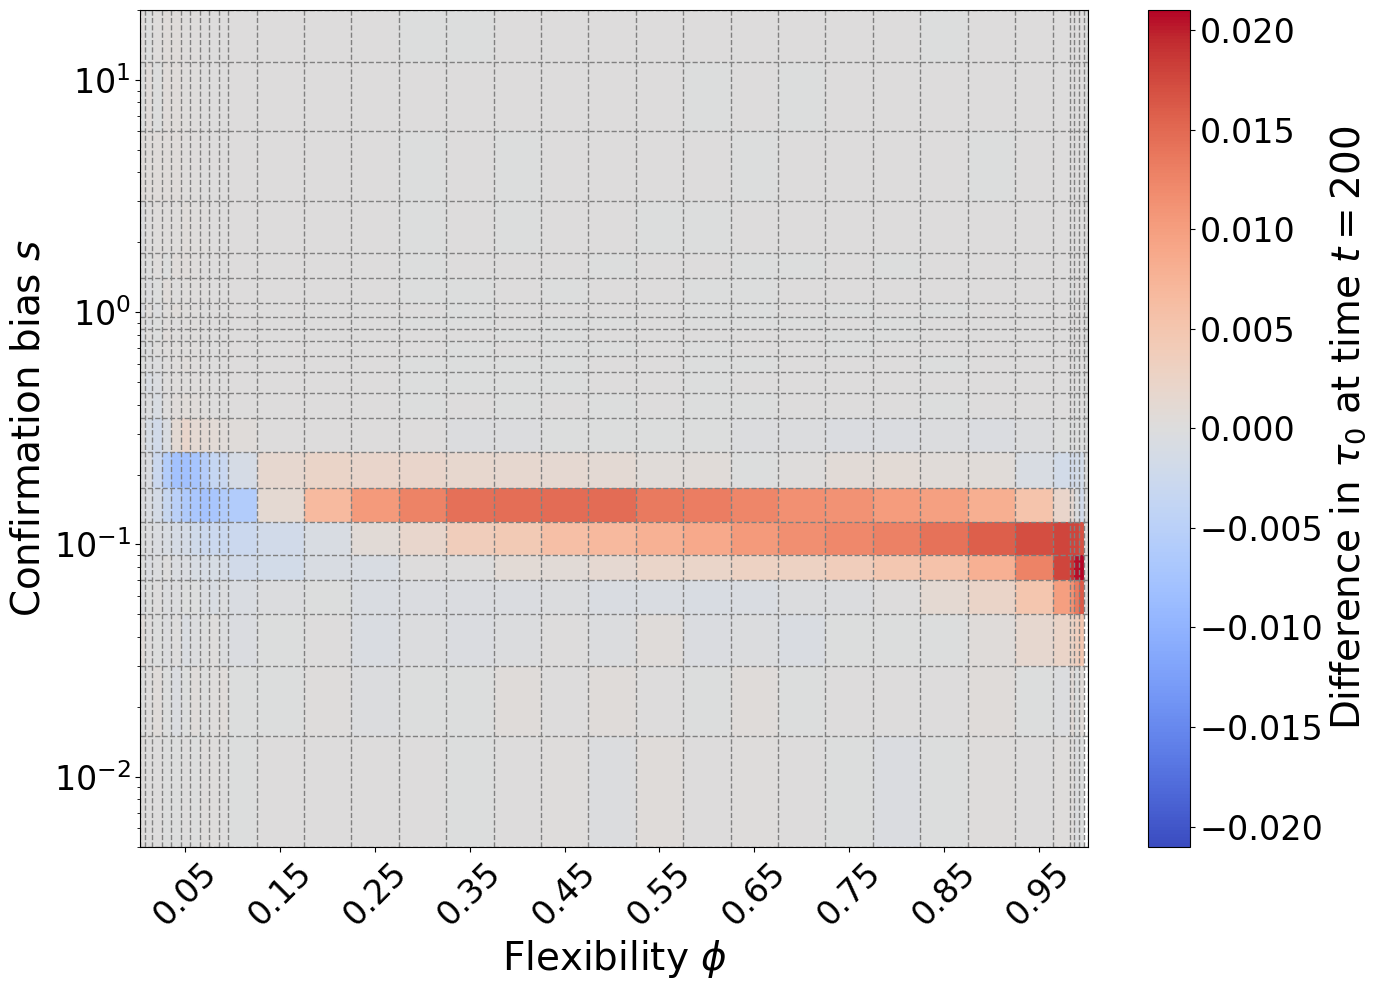

<Figure size 1400x1000 with 0 Axes>

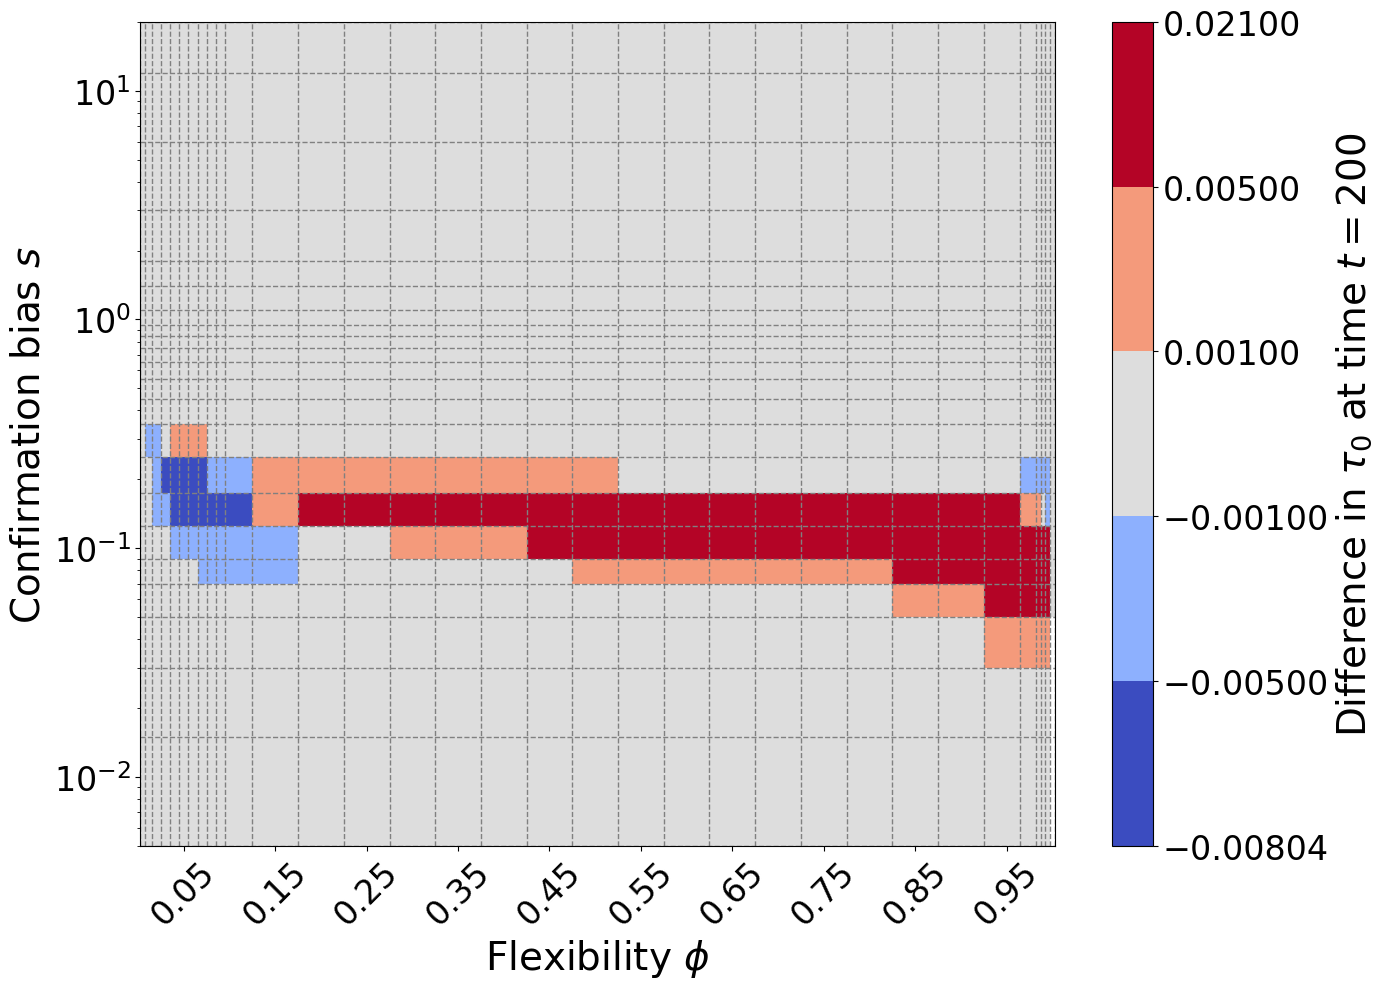

In [2]:
SQUARE_data_root = Path("N4096_new\combined_results")  # adjust to where your results live
BA_data_root = Path("N4096_BA\combined_results")  # adjust to where your results live
output_dir = Path("differences")

df_SQUARE = pd.read_csv(SQUARE_data_root / "summary_square_final.csv")
df_BA = pd.read_csv(BA_data_root / "summary_ba_final.csv")

plot_differences(df_SQUARE, df_BA, "T3", Path(f"square-BA_phase_diagram_T3.png"), Path(r'differences'))
plot_differences(df_SQUARE, df_BA, "T2", Path(f"square-BA_phase_diagram_T2.png"), Path(r'differences'))
plot_differences(df_SQUARE, df_BA, "T1", Path(f"square-BA_phase_diagram_T1.png"), Path(r'differences'))
plot_differences(df_SQUARE, df_BA, "T0", Path(f"square-BA_phase_diagram_T0.png"), Path(r'differences'))

<Figure size 1000x670 with 0 Axes>

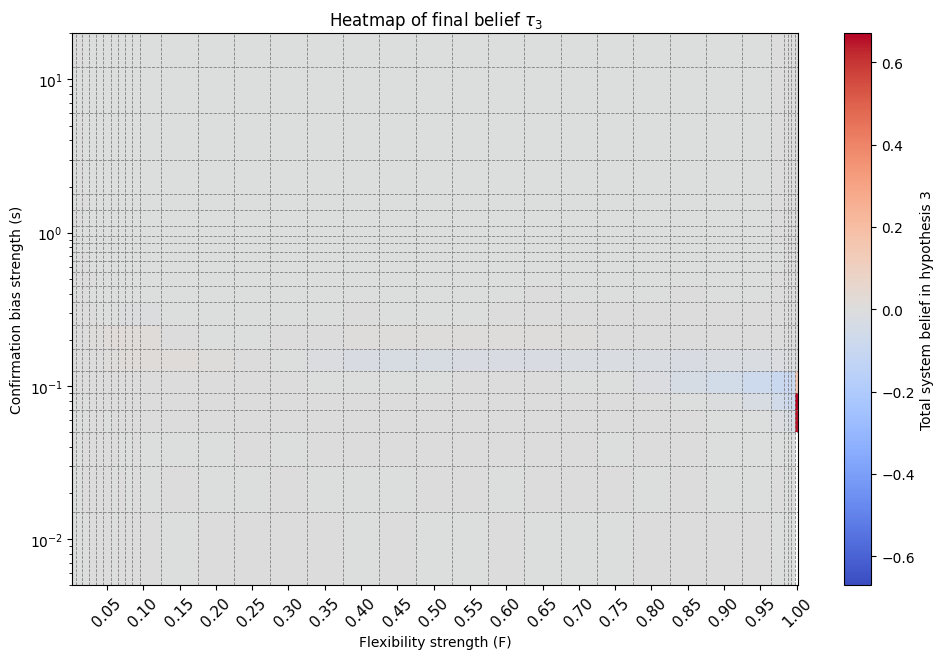

C:\Users\audso\AppData\Local\Temp\ipykernel_14308\3159082248.py:96: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("coolwarm", n_bins)


<Figure size 1000x670 with 0 Axes>

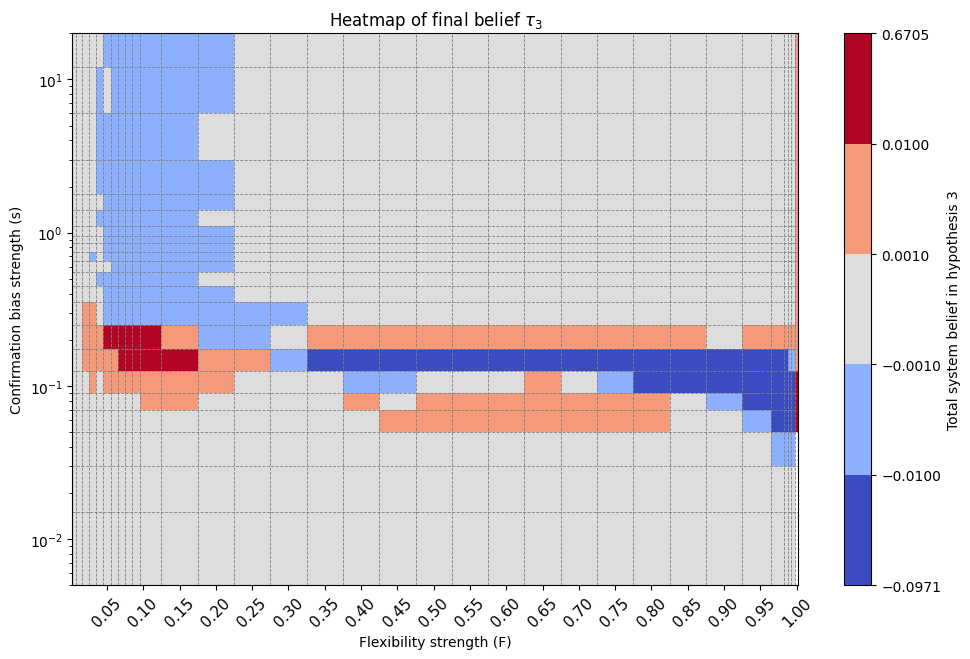

In [27]:
# === Configuration ===
SQUARE_data_root = Path("N4096_new\combined_results")  # adjust to where your results live
BA_data_root = Path("N4096_BA\combined_results")  # adjust to where your results live
output_dir = Path("differences")
output_dir.mkdir(exist_ok=True, parents=True)

FLEX_STRENGTH_values = [
    0.005, 0.01, 0.02, 0.03, 0.04, 0.050, 0.06, 0.07, 0.08, 0.09,
    0.100, 0.150, 0.200, 0.250, 0.300, 0.350, 0.400,
    0.450, 0.500, 0.550, 0.600, 0.650, 0.700, 0.750, 0.800,
    0.850, 0.900, 0.950, 0.980, 0.985, 0.990, 0.995, 1.000
]

S_values = [
    0.01, 0.02, 0.04, 0.06, 0.08, 0.15, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.2, 1.6, 2, 4, 8, 16
]
X, Y = np.meshgrid(FLEX_STRENGTH_values, S_values)

df_SQUARE = pd.read_csv(SQUARE_data_root / "summary_square_final.csv")
df_BA = pd.read_csv(BA_data_root / "summary_ba_final.csv")

metric = "T3" 
pivot_SQUARE = df_SQUARE.pivot(index="S", columns="F", values=metric)
pivot_SQUARE.index = pivot_SQUARE.index.astype(float)
pivot_SQUARE.columns = pivot_SQUARE.columns.astype(float)
pivot_BA = df_BA.pivot(index="S", columns="F", values=metric)
pivot_BA.index = pivot_BA.index.astype(float)
pivot_BA.columns = pivot_BA.columns.astype(float)


pivot_SQUARE = pivot_SQUARE.sort_index(axis=0, ascending=False).sort_index(axis=1)
pivot_BA = pivot_BA.sort_index(axis=0, ascending=False).sort_index(axis=1)

def compute_edges(arr):
    arr = np.asarray(arr)
    edges = (arr[:-1] + arr[1:]) / 2
    edges = np.concatenate([[arr[0] - (edges[0] - arr[0])], edges, [arr[-1] + (arr[-1] - edges[-1])]])
    return edges

plt.figure(figsize=(10, 6.7))
fig, ax = plt.subplots(figsize=(10, 6.7))

# Convert pivot to numpy
Z = pivot_SQUARE.values - pivot_BA.values
x = pivot_SQUARE.columns.values
y = pivot_SQUARE.index.values
x_edges = compute_edges(x)
y_edges = compute_edges(y)

vmax = np.nanmax(np.abs(Z))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

mesh = ax.pcolormesh(
    x, y, Z,
    cmap="coolwarm",
    norm=norm,
    # vmin=0.24,
    # vmax=1.0,
    # cmap=cmap,
    # norm=norm,
    # shading="nearest"
)

for xv in x_edges:
    ax.axvline(xv, color="gray", linestyle="--", linewidth=0.6)
for yv in y_edges:
    ax.axhline(yv, color="gray", linestyle="--", linewidth=0.6)

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label(f"Total system belief in hypothesis {metric[1]}")
ax.set_yscale('log')
# ax.set_xscale('log')
plt.title(fr"Heatmap of final belief $\tau_{metric[-1]}$")
plt.xlabel("Flexibility strength (F)")
plt.ylabel("Confirmation bias strength (s)")
plt.xticks(np.arange(0.05, 1.05, step=0.05), fontsize=11, rotation=45)
# plt.yticks(S_values, fontsize=11)
plt.tight_layout()
out_path = output_dir / f"heatmap_logy_{metric}.png"
plt.savefig(out_path, dpi=300)
plt.show()

plt.figure(figsize=(10, 6.7))
fig, ax = plt.subplots(figsize=(10, 6.7))

# Convert pivot to numpy
Z = pivot_SQUARE.values - pivot_BA.values
x = pivot_SQUARE.columns.values
y = pivot_SQUARE.index.values
x_edges = compute_edges(x)
y_edges = compute_edges(y)

vmax = np.nanmax(np.abs(Z))
n_bins = 5
bounds = [np.nanmin(Z), -1e-2, -1e-3, 1e-3, 1e-2, vmax]
cmap = cm.get_cmap("coolwarm", n_bins)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

mesh = ax.pcolormesh(
    x, y, Z,
    cmap=cmap,
    norm=norm,
    # vmin=0.24,
    # vmax=1.0,
    # cmap=cmap,
    # norm=norm,
    shading="nearest"
)

for xv in x_edges:
    ax.axvline(xv, color="gray", linestyle="--", linewidth=0.6)
for yv in y_edges:
    ax.axhline(yv, color="gray", linestyle="--", linewidth=0.6)

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label(f"Total system belief in hypothesis {metric[1]}")
ax.set_yscale('log')
# ax.set_xscale('log')
plt.title(fr"Heatmap of final belief $\tau_{metric[-1]}$")
plt.xlabel("Flexibility strength (F)")
plt.ylabel("Confirmation bias strength (s)")
plt.xticks(np.arange(0.05, 1.05, step=0.05), fontsize=11, rotation=45)
# plt.yticks(S_values, fontsize=11)
plt.tight_layout()
out_path = output_dir / f"heatmap_logy_{metric}.png"
plt.savefig(out_path, dpi=300)
plt.show()